# Importing Required Libraries

In this step, all the required Python libraries for data preprocessing, visualization, feature engineering, and feature selection are imported successfully.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Loading the Dataset

The Adult dataset is loaded into a Pandas DataFrame. This dataset contains census information used to predict whether income exceeds 50K per year.

In [5]:
!
!pip install ppscore
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler
import ppscore as pps

df=pd.read_csv('/content/adult_with_headers.csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Basic Data Exploration

Basic exploration is performed to understand the structure and characteristics of the dataset.

The following operations are performed:
- Checking dataset shape
- Viewing first few records
- Understanding data types
- Generating statistical summaries

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [9]:
df.shape

(32561, 15)

# Checking Missing Values

Missing values are checked to identify incomplete records in the dataset.

Handling missing values is important because missing data may negatively affect machine learning model performance.

In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(32537, 15)

In [14]:
cat_cols=df.select_dtypes('object').columns
num_cols=df.select_dtypes('int64').columns
print(cat_cols)
num_cols

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

# Encoding Techniques

Encoding techniques are used to convert categorical variables into numerical format because machine learning algorithms cannot directly process categorical data.

# Label Encoding

Label Encoding converts categorical values into numerical labels.

It is applied to categorical columns having more than 5 categories.

### Advantages
- Memory efficient
- Faster implementation

### Disadvantages
- Introduces ordinal relationships

# One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category.

It is applied to categorical columns having fewer than 5 categories.

### Advantages
- Removes ordinal relationship
- Suitable for nominal data

### Disadvantages
- Increases dimensionality

In [15]:
le = LabelEncoder()

high_cat = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship'
]

for col in high_cat:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(
    df,
    columns=['race','sex','native_country','income']
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia,income_ <=50K,income_ >50K
0,39,7,77516,9,13,4,1,1,2174,0,...,False,False,False,False,False,True,False,False,True,False
1,50,6,83311,9,13,2,4,0,0,0,...,False,False,False,False,False,True,False,False,True,False
2,38,4,215646,11,9,0,6,1,0,0,...,False,False,False,False,False,True,False,False,True,False
3,53,4,234721,1,7,2,6,0,0,0,...,False,False,False,False,False,True,False,False,True,False
4,28,4,338409,9,13,2,10,5,0,0,...,False,False,False,False,False,False,False,False,True,False


# Removing Duplicate Records

Duplicate records are identified and removed to improve data quality and reduce redundancy in the dataset.

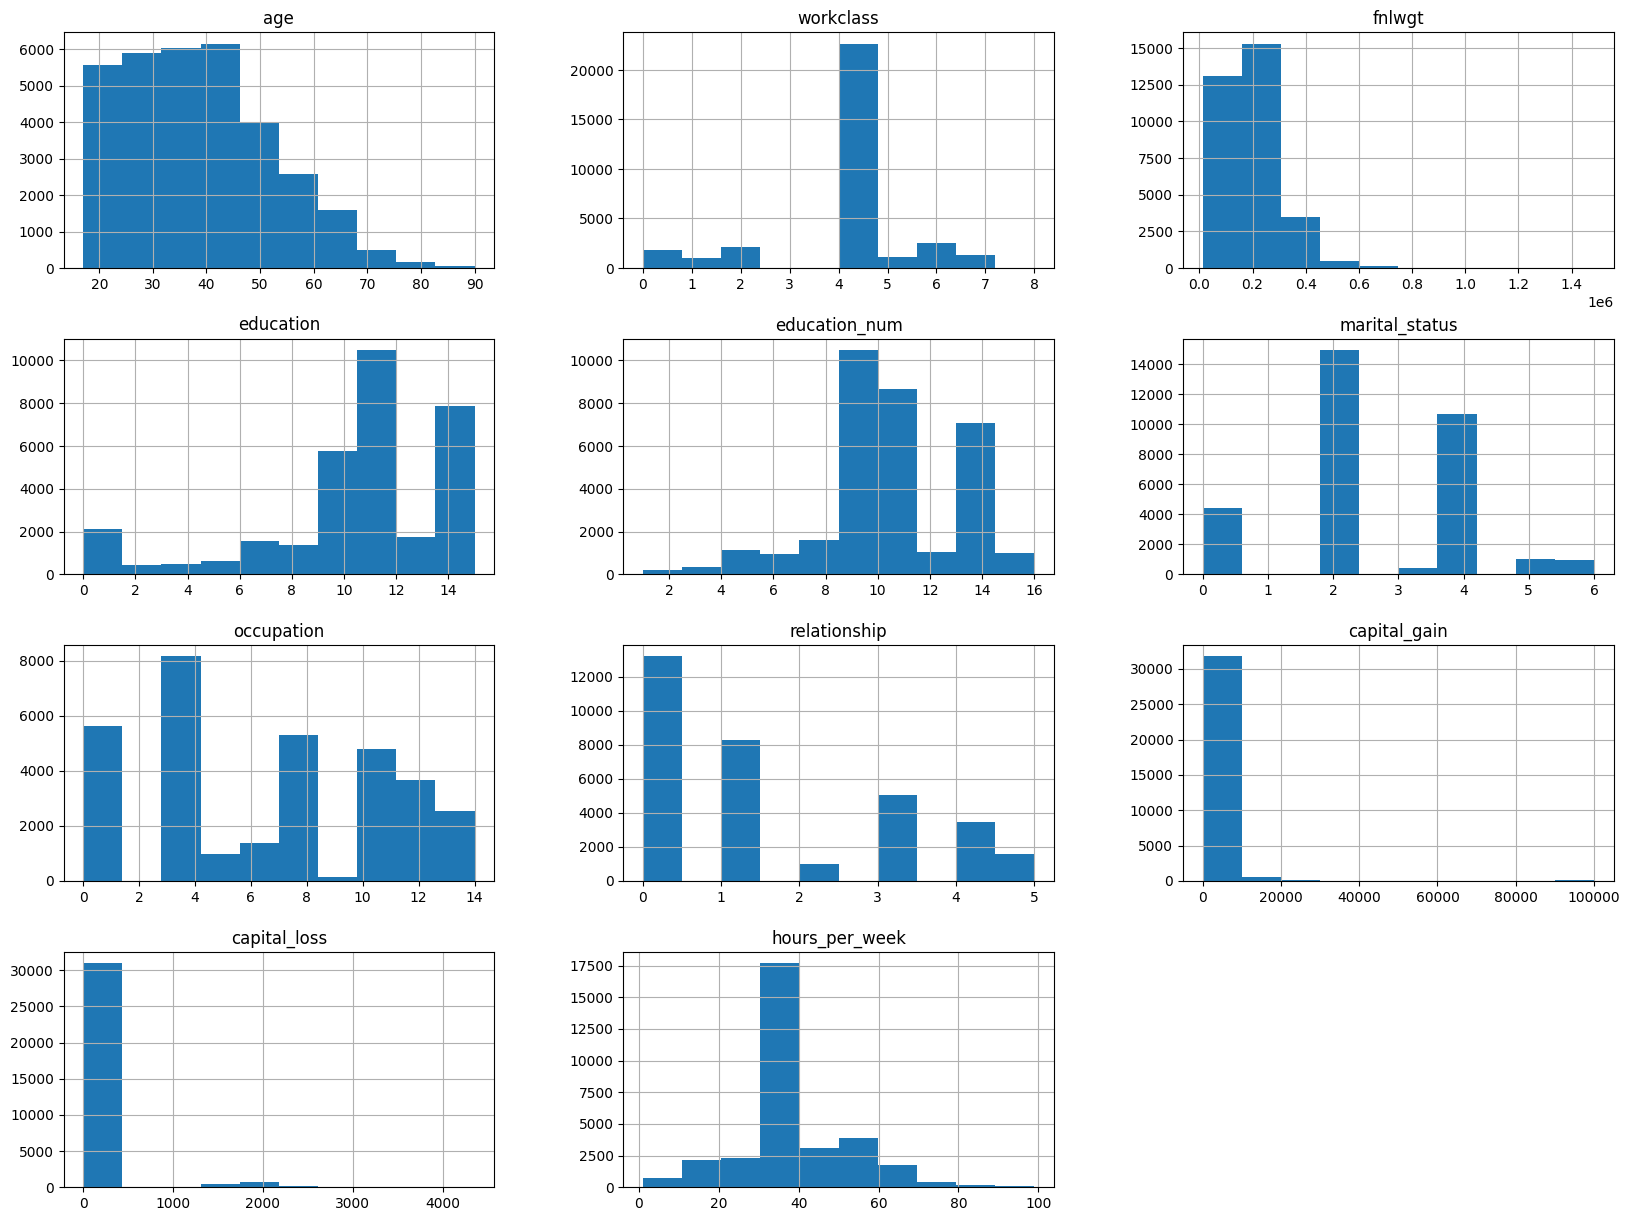

In [16]:
df.hist(figsize=(20,15))
plt.show()

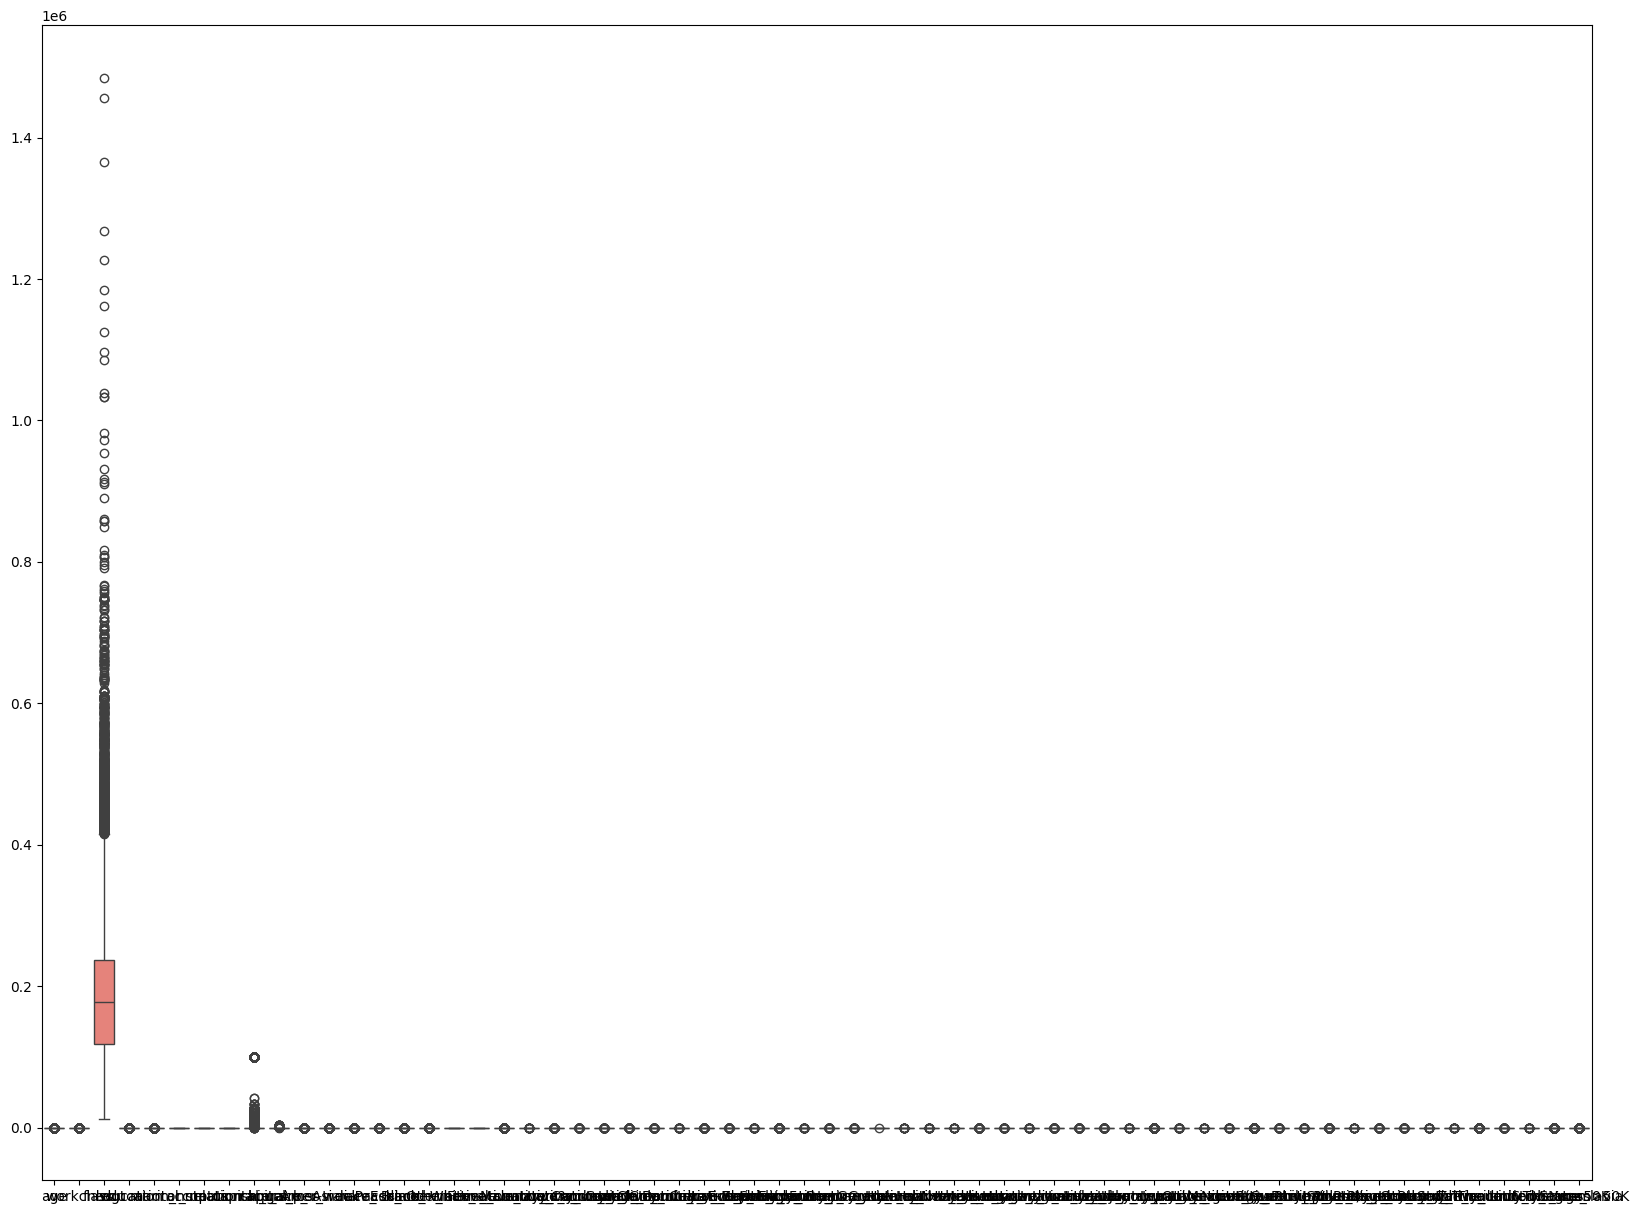

In [17]:
plt.figure(figsize=(20,15))
sns.boxplot(df)
plt.show()

In [18]:
df.skew()

,0
age,0.557663
workclass,-0.751598
fnlwgt,1.447703
education,-0.934160
education_num,-0.309500
...,...
native_country_ United-States,-2.594542
native_country_ Vietnam,21.969830
native_country_ Yugoslavia,45.063846
income_ <=50K,-1.211687


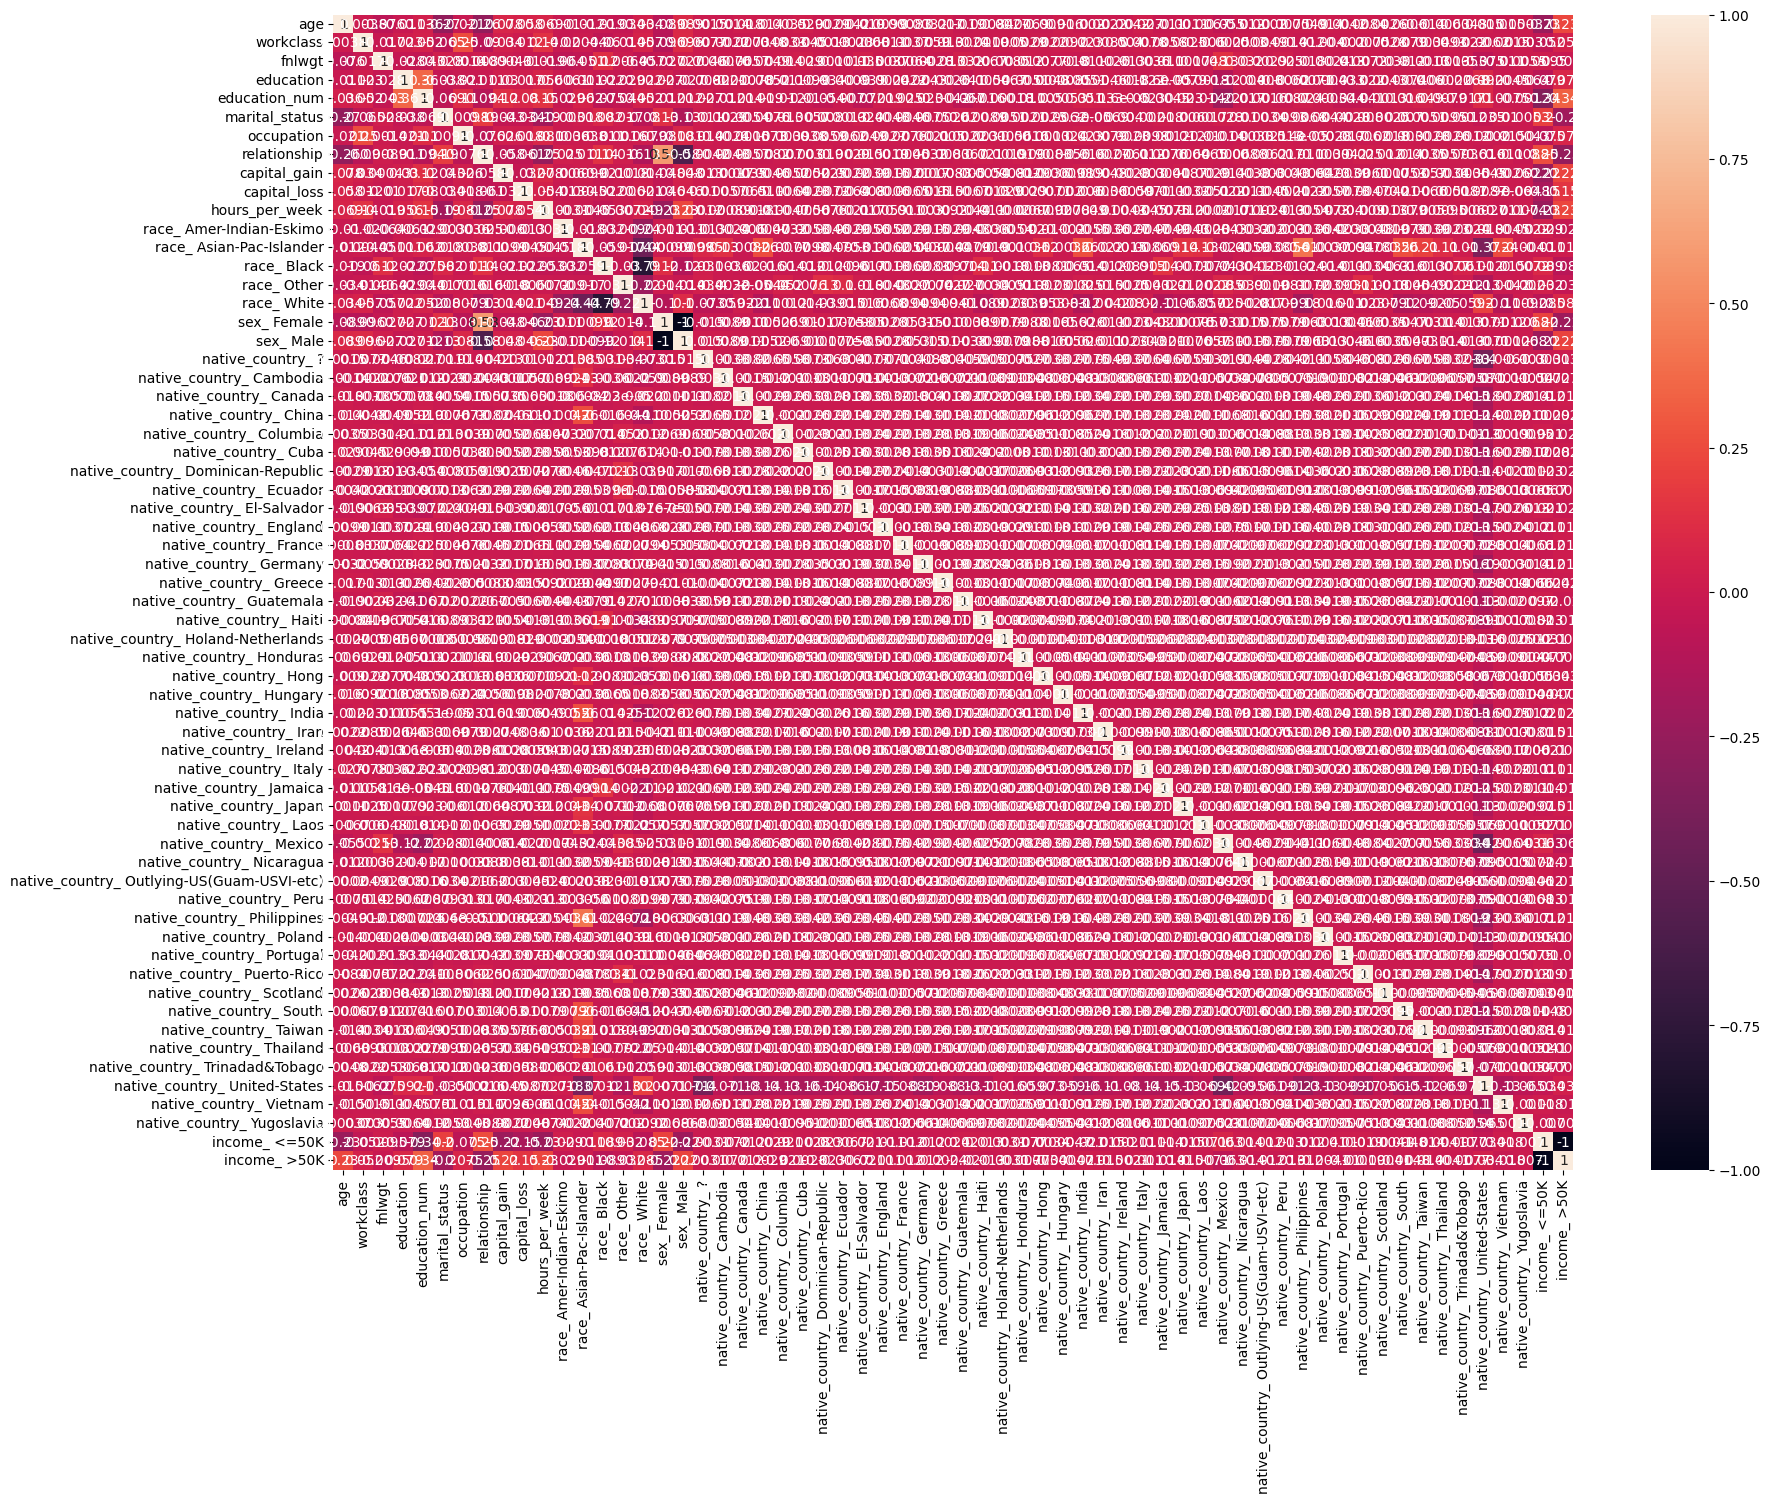

In [19]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

# Standard Scaling

Standard Scaling transforms data so that the mean becomes 0 and the standard deviation becomes 1.

This scaling technique is useful for algorithms such as Logistic Regression, SVM, and PCA.

# Min-Max Scaling

Min-Max Scaling transforms feature values into a fixed range between 0 and 1.

This technique is useful when bounded feature values are required.

In [20]:
ss = StandardScaler()
mm = MinMaxScaler()

scaled_standard = ss.fit_transform(df[num_cols])
scaled_minmax = mm.fit_transform(df[num_cols])

# Predictive Power Score (PPS)

Predictive Power Score measures predictive relationships between features.

Unlike correlation, PPS can detect both linear and non-linear relationships.

In [21]:
pps_matrix = pps.matrix(df)

pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.7392,0.886143,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,75736.2438,77225.235712,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.7196,2.728949,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.8652,1.906863,DecisionTreeRegressor()
